In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
# from scikit_posthocs import posthoc_dunn
# from scipy.stats import f_oneway, kruskal
import scipy.stats as st
# from statannotations.Annotator import Annotator
import statsmodels.api as sm
import matplotlib.colors as mcolors


# sns.set_context("notebook", font_scale=1.5)  # Adjust font_scale to increase font size
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')




# Analyse CFU data from community assembly 1
Correlations, rank distributions etc

In [2]:
repo_folder = Path("../..")
gp_folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "2_community_assembly"
figure_folder.mkdir(parents=True, exist_ok=True)


## Read in data

In [3]:
data_folder = Path("../../data/2_first_community_assembly")
file_to_open = data_folder / "cfus.csv"
df = pd.read_csv(file_to_open, index_col=0)

In [4]:
wellmap_fn = data_folder / "wellmap.csv"
wellmap_df = pd.read_csv(wellmap_fn, index_col=0)
wellmap_df['Carbon source'] = wellmap_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
well_to_cs = wellmap_df.set_index('Well').to_dict()['Carbon source']
well_to_rep = wellmap_df.set_index('Well').to_dict()['Replicate']

In [5]:
shannon_df = pd.read_csv(data_folder / 'shannon_index.csv', index_col=0)

In [6]:
well_to_shannon = shannon_df['Shannon index'].to_dict()

In [7]:
palette = sns.palettes.color_palette('tab10')
palette = [palette[i] for i in [2,1,0,3]]

In [8]:
strains = ['At', 'Ct', 'Ml', 'Oa']

In [9]:
df['Carbon source'] = df['Carbon source'].str.replace('L-', '').str.replace('D-','')
df = df.loc[df['Carbon source'].notna()]

In [10]:
cs_class_fn = gp_folder / 'selected_carbon_sources.csv'
cs_class_df = pd.read_csv(cs_class_fn)
cs_class_df.rename(columns={'Metabolite name': 'Carbon source'}, inplace=True)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_class_df.replace({'Metabolite class': {'Alcohol': 'Other', 'Nucleoside': 'Other', 'Simple sugar':'Sugar'}}, inplace=True)
cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Metabolite class']

well_to_class = {}
for well, cs in well_to_cs.items():
    if cs == 'No CS':
        well_to_class[well] = 'No CS'
    else:
        try:
            well_to_class[well] = cs_to_class[cs]
        except KeyError:
            well_to_class[well] = 'Mix'

# well_to_cs_type = {well:cs_to_cs_type[cs] for well, cs in cs_class_df.items() if not '+' in cs and not (cs == 'No CS')}

# Read in growth data

In [11]:


rate_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)
rate_df['Carbon source'] = rate_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()
rate_df['# CS'] = 1
rate_df.loc[rate_df['Carbon source'] == 'No cs', '# CS'] = 0
rate_df.replace({'max_growth_rate':{np.nan:0}}, inplace=True)



In [12]:
# rate_df.replace({'lag':{np.nan:0}}, inplace=True)
# rate_df.replace({'Yield':{np.nan:1}}, inplace=True)
# rate_df.replace({'y0':{np.nan:1}}, inplace=True)

In [13]:
# lag_flag = True
# if lag_flag:
rate_df["Effective growth rate"] = rate_df["max_growth_rate"]*(rate_df["Yield"] - rate_df["y0"])/(rate_df["max_growth_rate"]*rate_df["lag"] + np.log(rate_df["Yield"]/rate_df["y0"]))

In [14]:
rate_df.replace({'max_growth_rate':{np.nan:0}, 'Effective growth rate': {np.nan: 0}}, inplace=True)

In [15]:
# First, calculate the max growth rate of the carbon source pairs as the sume of the growthr ate on the individuals
double_cs = sorted([x for x in df['Carbon source'].unique() if '+' in x])
double_rates = []
for cs_pair in double_cs:
    cs1, cs2 = cs_pair.split(' + ')
    for strain in strains:
        rate1 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs1), 'max_growth_rate'].values[0]
        rate2 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs2), 'max_growth_rate'].values[0]
        erate1 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs1), 'Effective growth rate'].values[0]
        erate2 = rate_df.loc[(rate_df['Species'] == strain) & (rate_df['Carbon source'] == cs2), 'Effective growth rate'].values[0]
        double_rates.append({'Species': strain, 'Carbon source': cs_pair, 'max_growth_rate': rate1 + rate2, 'Effective growth rate': erate1 + erate2})
double_rate_df = pd.DataFrame(double_rates)
double_rate_df['# CS'] = 2
rate_df = pd.concat([rate_df, double_rate_df])

## Compute rank

In [16]:
df_mean78 = df.loc[df.Batch.isin([7, 8])].groupby(['Strain', 'Carbon source']).agg({'CFUs/mL':['mean', 'std']}).reset_index()    

# Group by 'Carbon source' and rank species by abundance
df_mean78[('Abundance rank', '')] = df_mean78.groupby([('Carbon source', '')]).rank(ascending=False, method='min')[( 'CFUs/mL', 'mean')]
df_mean78.columns = ['Species', 'Carbon source', 'Mean CFUs/mL', 'Std CFUs/mL', 'Abundance rank']



### Rank from monoculture data

In [17]:
rate_df['Growth rate rank'] = rate_df[['Carbon source','Species','max_growth_rate']].groupby('Carbon source').rank(ascending=False, method='min')['max_growth_rate']
rate_df['Effective growth rate rank'] = rate_df[['Carbon source','Species','Effective growth rate']].groupby('Carbon source').rank(ascending=False, method='min')['Effective growth rate']

In [18]:
df_mean78 = pd.merge(left = df_mean78, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS', 'Effective growth rate', 'Effective growth rate rank']], on = ['Carbon source', 'Species'], how = 'left')

In [19]:
df_mean78 = df_mean78.loc[df_mean78['# CS'].isin([1,2])]

In [20]:
df_mean78.loc[~df_mean78['Growth rate rank'].notna()]

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank


In [21]:
nanidx = df_mean78['Growth rate rank'].notna()
st.spearmanr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank'])
st.pearsonr(df_mean78.loc[nanidx, 'Growth rate rank'], df_mean78.loc[nanidx, 'Abundance rank'])

# st.pearsonr(df_mean78.loc[~nanidx, 'Abundance rank'], df_mean78.loc[~nanidx, 'Growth rate rank'])

PearsonRResult(statistic=np.float64(0.3855885298613674), pvalue=np.float64(9.756328193613534e-06))

In [22]:
idx1 = nanidx & (df_mean78['# CS'] == 1)
idx2 = nanidx & (df_mean78['# CS'] == 2)
print(st.spearmanr(df_mean78.loc[idx1, 'Growth rate rank'], df_mean78.loc[idx1, 'Abundance rank']))
print(st.spearmanr(df_mean78.loc[idx2, 'Growth rate rank'], df_mean78.loc[idx2, 'Abundance rank']))


SignificanceResult(statistic=np.float64(0.5000854826103946), pvalue=np.float64(2.581524931889803e-05))
SignificanceResult(statistic=np.float64(0.26666666666666666), pvalue=np.float64(0.039437063761087694))


# Create adjusted abundance rank prediction from growth rate ranks


In [23]:
auxotrophs = ['Oa', 'Ml']
prototrophs = ['At', 'Ct']
for i, cs in enumerate(df_mean78['Carbon source'].unique()):
    df_cs = df_mean78[df_mean78['Carbon source'] == cs].copy()
    df_cs.sort_values('Effective growth rate rank', inplace=True)
    j=0
    while j<4:
        if df_cs.iloc[j]['Species'] in prototrophs:
            break
        j+=1 
    # if j == 0:
    # print(cs, j)
    
    for k, (idx, row) in enumerate(df_cs.iterrows()):
        if k<j:
            df_mean78.at[idx, 'Predicted rank'] = row['Effective growth rate rank']+1
        elif k == j:
            df_mean78.at[idx, 'Predicted rank'] = 1
        else:
            df_mean78.at[idx, 'Predicted rank'] = row['Effective growth rate rank']

In [24]:
# df_mean78.sort_values(['Carbon source','Predicted rank']).iloc[100:]

# Prepare the data for the linear model
# Ensure there are no missing values in the relevant columns
df_clean = df_mean78.dropna(subset=['Abundance rank', 'Predicted rank', 'Growth rate rank', '# CS'])
for n_cs in [1, 2]:

    idx = df_clean['# CS'] == n_cs
    # Define the independent variables (predictors) and the dependent variable (response)
    X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
    X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
    y = df_clean.loc[idx, 'Abundance rank']  # Response

    # Add a constant to the predictors (for the intercept term)
    X1 = sm.add_constant(X1)
    X2 = sm.add_constant(X2)

    # Fit the linear model
    model1 = sm.OLS(y, X1).fit()
    model2 = sm.OLS(y, X2).fit()

    # Print the summary of the model
    print(f'Predicted rank R2 ({n_cs} cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
    print(f'Growth rate rank R2 ({n_cs} cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

idx = df_clean['# CS'].isin([1,2])
# Define the independent variables (predictors) and the dependent variable (response)
X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
y = df_clean.loc[idx, 'Abundance rank']  # Response

# Add a constant to the predictors (for the intercept term)
X1 = sm.add_constant(X1)
X2 = sm.add_constant(X2)

# Fit the linear model
model1 = sm.OLS(y, X1).fit()
model2 = sm.OLS(y, X2).fit()

# Print the summary of the model
print(f'Predicted rank R2 (1 and 2 cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
print(f'Growth rate rank R2 (1 and 2 cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

# print(model1.summary())
# print(model1.pvalues)

Predicted rank R2 (1 cs): 0.32, p-value: 1.21e-06
Growth rate rank R2 (1 cs): 0.25, p-value: 2.60e-05
Predicted rank R2 (2 cs): 0.31, p-value: 3.28e-06
Growth rate rank R2 (2 cs): 0.07, p-value: 3.94e-02
Predicted rank R2 (1 and 2 cs): 0.32, p-value: 1.10e-11
Growth rate rank R2 (1 and 2 cs): 0.15, p-value: 9.76e-06


In [25]:
# df_mean78.sort_values(['Carbon source','Predicted rank']).iloc[100:]
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Compute McFadden's R-squared
def compute_pseudo_r2(model):
    llf = model.llf  # Log-likelihood of the fitted model
    llnull = model.llnull  # Log-likelihood of the null model
    pseudo_r2 = 1 - (llf / llnull)  # McFadden's R-squared
    return pseudo_r2

# Prepare the data for the linear model
# Ensure there are no missing values in the relevant columns
df_clean = df_mean78.dropna(subset=['Abundance rank', 'Predicted rank', 'Growth rate rank', '# CS'])
for n_cs in [1, 2]:

    idx = df_clean['# CS'] == n_cs
    # Define the independent variables (predictors) and the dependent variable (response)
    X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
    X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
    y = df_clean.loc[idx, 'Abundance rank']  # Response


    # Fit the linear model
    model1 = OrderedModel(y, X1).fit()
    model2 = OrderedModel(y, X2).fit()

    print(model1.summary())
    print(model2.summary())
        # Calculate pseudo R-squared for both models
    pseudo_r2_model1 = compute_pseudo_r2(model1)
    pseudo_r2_model2 = compute_pseudo_r2(model2)

    # Print the results
    print(f"McFadden's R-squared for Predicted Rank: {pseudo_r2_model1:.4f}")
    print(f"McFadden's R-squared for Growth Rate Rank: {pseudo_r2_model2:.4f}")
    # # Print the summary of the model
    # print(f'Predicted rank R2 ({n_cs} cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
    # print(f'Growth rate rank R2 ({n_cs} cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

idx = df_clean['# CS'].isin([1,2])
# Define the independent variables (predictors) and the dependent variable (response)
X1 = df_clean.loc[idx, 'Predicted rank']  # Predictors
X2 = df_clean.loc[idx, 'Growth rate rank']  # Predictors
y = df_clean.loc[idx, 'Abundance rank']  # Response

# Fit the linear model
model1 = OrderedModel(y, X1, distr='logit').fit()
model2 = OrderedModel(y, X2, distr='logit').fit()

# Print the summary of the model
print(model1.summary())
# print(f'Predicted rank R2 (1 and 2 cs): {model1.rsquared:.2f}, p-value: {model1.f_pvalue:.2e}')
# print(f'Growth rate rank R2 (1 and 2 cs): {model2.rsquared:.2f}, p-value: {model2.f_pvalue:.2e}')

# print(model1.summary())
# print(model1.pvalues)


# Calculate pseudo R-squared for both models
pseudo_r2_model1 = compute_pseudo_r2(model1)
pseudo_r2_model2 = compute_pseudo_r2(model2)

# Print the results
print(f"McFadden's R-squared for Predicted Rank: {pseudo_r2_model1:.4f}")
print(f"McFadden's R-squared for Growth Rate Rank: {pseudo_r2_model2:.4f}")

Optimization terminated successfully.
         Current function value: 1.188792
         Iterations: 126
         Function evaluations: 215
Optimization terminated successfully.
         Current function value: 1.240549
         Iterations: 123
         Function evaluations: 206
                             OrderedModel Results                             
Dep. Variable:         Abundance rank   Log-Likelihood:                -76.083
Model:                   OrderedModel   AIC:                             160.2
Method:            Maximum Likelihood   BIC:                             168.8
Date:                Mon, 26 Jan 2026                                         
Time:                        10:28:30                                         
No. Observations:                  64                                         
Df Residuals:                      60                                         
Df Model:                           1                                         
         

In [26]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.017602,3.0,3.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.038394,3.0,3.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0,0.020792,2.0,1.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0,0.077715,2.0,1.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0,0.000000,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
122,Oa,Myo-inositol + Glutamate,1.533333e+08,4.320494e+07,3.0,1.0,0.613915,2.0,0.081695,3.0,3.0
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0,0.015348,3.0,3.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0,0.053914,1.0,2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0,0.030161,2.0,2.0


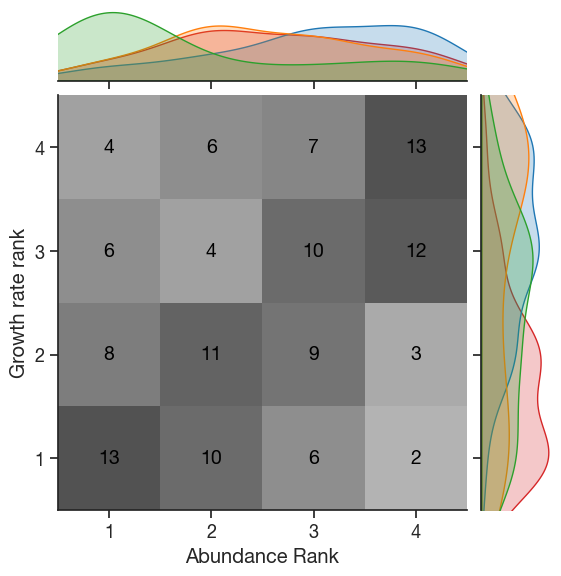

In [27]:

species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_mean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_mean78.loc[idx],
    x='Abundance rank',
    y='Growth rate rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance Rank')
g.ax_joint.set_ylabel('Growth rate rank')

    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_mean78.loc[idx, 'Abundance rank'],
    df_mean78.loc[idx, 'Growth rate rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank.pdf')



In [28]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.017602,3.0,3.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.038394,3.0,3.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0,0.020792,2.0,1.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0,0.077715,2.0,1.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0,0.000000,4.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...
122,Oa,Myo-inositol + Glutamate,1.533333e+08,4.320494e+07,3.0,1.0,0.613915,2.0,0.081695,3.0,3.0
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0,0.015348,3.0,3.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0,0.053914,1.0,2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0,0.030161,2.0,2.0


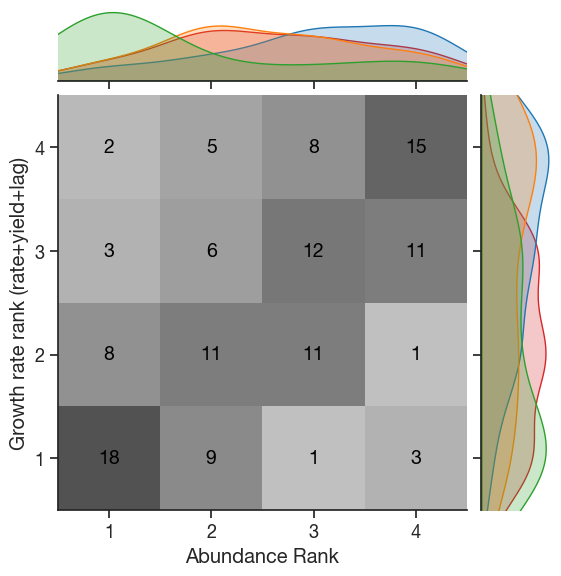

In [29]:

species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_mean78['# CS'].isin([1,2])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_mean78.loc[idx],
    x='Abundance rank',
    y='Effective growth rate rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance Rank')
g.ax_joint.set_ylabel('Growth rate rank (rate+yield+lag)')

    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_mean78.loc[idx, 'Abundance rank'],
    df_mean78.loc[idx, 'Effective growth rate rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'growth_rate_rank_vs_abundance_rank.pdf')



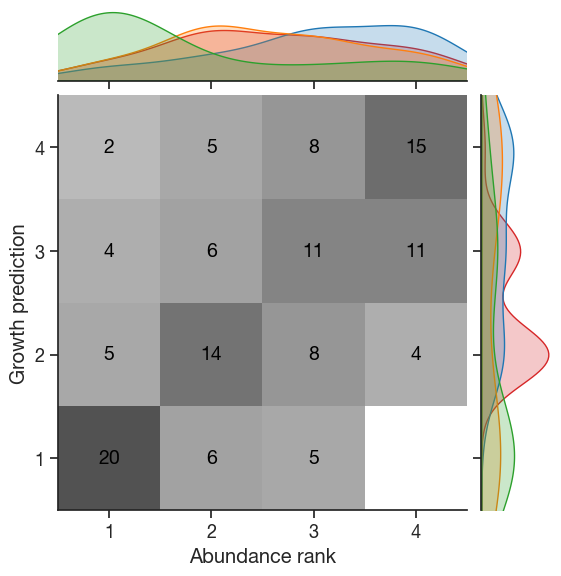

In [ ]:



species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot

idx = df_mean78['# CS'].isin([1])
# Create a jointplot for the current species
g = sns.JointGrid(
    data=df_mean78.loc[idx],
    x='Abundance rank',
    y='Predicted rank',
    # kind='hist',  # Use KDE for the main plot
    # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
    # bins=4,
    # height=6,
    # ratio=5

    # dropna=True,
    # discrete=(True, True),
    
    # fill=True,  # Fill the KDE plot
    # color = palette[i],
    # cmap = cmap,
    # cbar=True,  # Add
    # thresh=None,
    # cbar_kws=dict(shrink=.75)
    # cmap='viridis'  # Choose a colormap
)
g.plot_joint(sns.histplot, discrete=(True, True), bins = 4, color = 'gray')  
g.plot_marginals(sns.kdeplot, palette=palette, fill=True, hue='Species', hue_order=species_list,data=df_mean78.loc[idx], common_grid=True, common_norm=False)

    # Add a regression line to the main axes
# sns.regplot(
#     data=species_data,
#     x='Abundance rank',
#     y='Growth rate rank',
#     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
#     ax=g.ax_joint,
#     color='black',  # Color of the regression line
#     line_kws={'linewidth': 2}  # Customize the regression line
# )
g.ax_joint.set_xlim(0.5, 4.5)
g.ax_joint.set_ylim(0.5, 4.5)
g.ax_joint.set_yticks([1, 2, 3, 4])  # Force y-axis ticks to be 1, 2, 3, 4

# Customize the plot
g.ax_joint.set_xlabel('Abundance rank')
g.ax_joint.set_ylabel('Growth prediction')
    # g.ax_joint.set_title(f'Jointplot: {species}')
    # Annotate each square with the count
hist_data, x_edges, y_edges = np.histogram2d(
    df_mean78.loc[idx, 'Abundance rank'],
    df_mean78.loc[idx, 'Predicted rank'],
    bins=4
)

# Loop through the bins and annotate
for i in range(len(x_edges) - 1):
    for j in range(len(y_edges) - 1):
        # Compute the center of each bin
        x = (x_edges[i] + x_edges[i + 1]) / 2
        y = (y_edges[j] + y_edges[j + 1]) / 2
        count = int(hist_data[i, j])
        if count > 0:  # Only annotate non-empty bins
            g.ax_joint.text(i+1, j+1, count, ha='center', va='center', fontsize=14, color='black', fontdict={'weight': 'regular'})

plt.savefig(figure_folder / 'predicted_rank_vs_abundance_rank.pdf')


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14768/637117360.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


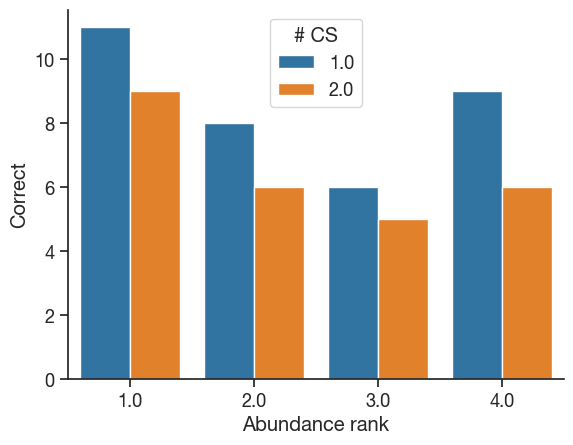

In [31]:
# Plot a small bar chart showin the number of correct predictions for each abundance rank
idxc = df_mean78['Abundance rank'] == df_mean78['Predicted rank']
correct_df = df_mean78.loc[idxc].groupby(['Abundance rank', '# CS']).size()
sns.barplot(
    data=correct_df.reset_index(name='Correct'),
    x='Abundance rank',
    y='Correct',
    hue = '# CS',
    estimator=np.mean,
    ci=None,
    palette = 'tab10'
    # color='gray'
)
sns.despine()

In [32]:
correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
correct_growth = (df_mean78.loc[idx, 'Growth rate rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
total = len(df_mean78.loc[idx])
print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

mad_pred = (df_mean78.loc[idx, 'Predicted rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
mad_growth = (df_mean78.loc[idx, 'Growth rate rank'] - df_mean78.loc[idx, 'Abundance rank']).abs().sum()/total
print(f'MAD predicted: {mad_pred:.2f}')
print(f'MAD growth: {mad_growth:.2f}')

Correctly predicted: 60/124 (0.48)
Correctly growth: 47/124 (0.38)
MAD predicted: 0.69
MAD growth: 0.89


In [33]:
idx1 = df_mean78['# CS'] == 1
correct_pred = (df_mean78.loc[idx1, 'Predicted rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
correct_growth = (df_mean78.loc[idx1, 'Growth rate rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
total = len(df_mean78.loc[idx1])
print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

mad_pred = (df_mean78.loc[idx1, 'Predicted rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
mad_growth = (df_mean78.loc[idx1, 'Growth rate rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
print(f'MAD predicted: {mad_pred:.2f}')
print(f'MAD growth: {mad_growth:.2f}')

Correctly predicted: 34/64 (0.53)
Correctly growth: 29/64 (0.45)
MAD predicted: 0.66
MAD growth: 0.75


In [34]:
idx1 = df_mean78['# CS'] == 2
correct_pred = (df_mean78.loc[idx1, 'Predicted rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
correct_growth = (df_mean78.loc[idx1, 'Growth rate rank'] == df_mean78.loc[idx1, 'Abundance rank']).sum()
total = len(df_mean78.loc[idx1])
print(f'Correctly predicted: {correct_pred}/{total} ({correct_pred/total:.2f})')
print(f'Correctly growth: {correct_growth}/{total} ({correct_growth/total:.2f})')

mad_pred = (df_mean78.loc[idx1, 'Predicted rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
mad_growth = (df_mean78.loc[idx1, 'Growth rate rank'] - df_mean78.loc[idx1, 'Abundance rank']).abs().sum()/total
print(f'MAD predicted: {mad_pred:.2f}')
print(f'MAD growth: {mad_growth:.2f}')

Correctly predicted: 26/60 (0.43)
Correctly growth: 18/60 (0.30)
MAD predicted: 0.73
MAD growth: 1.03


In [35]:
df_mean78.loc[df_mean78['Abundance rank'] != df_mean78['Predicted rank'], 'Species'].value_counts()

Species
Ct    20
Ml    18
Oa    16
At    10
Name: count, dtype: int64

In [36]:
mean_shannon = shannon_df.groupby('CS')['Shannon index'].mean().to_dict()

In [37]:
df_mean78['Shannon index'] = df_mean78['Carbon source'].map(mean_shannon)

In [38]:
mean_shannon

{'Acetate': 1.714034661230805,
 'Acetate + Alanine': 1.7526918179057096,
 'Alanine': 1.0656039809941602,
 'Alanine + Glucose': 0.9586114644516338,
 'Citrate': 1.5662231660557986,
 'Citrate + Glucose': 1.5454523408236043,
 'Glucose': 0.3768748120997383,
 'Glutamate': 1.5758215962926403,
 'Glutamate + Mannose': 1.0737098370283393,
 'Glutarate': 1.1217251664050218,
 'Glutarate + Inosine': 1.458111552566142,
 'Glycerol': 0.2521737312930945,
 'Glycerol + Inosine': 0.29642523235396817,
 'Glycerol + Isoleucine': 1.3250513308883372,
 'Histidine': 1.4494258696708904,
 'Histidine + Mannose': 1.008865475203091,
 'Inosine': 1.3050427360721388,
 'Isoleucine': 0.3435377442652831,
 'Malate': 1.7643614297760903,
 'Malate + Citrate': 1.5155331741487152,
 'Malate + Isoleucine': 0.832205450344385,
 'Mannitol': 0.3139209642533724,
 'Mannitol + Acetate': 1.0902796580166472,
 'Mannitol + Myo-inositol': 0.43840651926315605,
 'Mannose': 0.5054235329404874,
 'Myo-inositol': 0.4473256681629583,
 'Myo-inositol +

In [39]:
shannon_df['Predicted rank 1'] = shannon_df['CS'].map(lambda cs: df_mean78.loc[(df_mean78['Carbon source'] == cs) & (df_mean78['Growth rate rank'] == 1), 'Species'].values[0])


In [40]:
shannon_df['Prototroph predicted rank 1'] = shannon_df['Predicted rank 1'].isin(['At', 'Ct'])

<Axes: xlabel='Prototroph predicted rank 1', ylabel='Shannon index'>

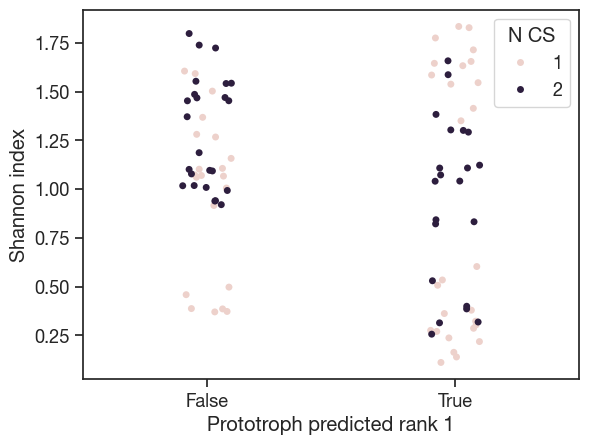

In [41]:
sns.stripplot(data=shannon_df, x='Prototroph predicted rank 1', y='Shannon index', hue = 'N CS')

In [42]:
df_mean78.loc[df_mean78['Growth rate rank']==1].sort_values('Shannon index').head(40)

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Shannon index
30,At,Xylose,5.733333e+09,2.637170e+09,1.0,1.0,0.242237,1.0,0.057158,1.0,1.0,0.156391
11,At,Glycerol,1.100000e+10,2.756810e+09,1.0,1.0,0.190830,1.0,0.040936,1.0,1.0,0.252174
12,At,Glycerol + Inosine,5.233333e+09,1.023067e+09,1.0,1.0,0.224954,2.0,0.042354,1.0,1.0,0.296425
21,At,Mannitol,3.300000e+09,4.335897e+08,1.0,1.0,0.425818,1.0,0.053223,1.0,1.0,0.313921
49,Ct,Isoleucine,6.866667e+09,1.632993e+09,1.0,1.0,0.078777,1.0,0.010589,1.0,1.0,0.343538
102,Oa,Glucose,4.133333e+08,1.170755e+08,2.0,1.0,0.339315,1.0,0.044475,2.0,2.0,0.376875
23,At,Mannitol + Myo-inositol,2.466667e+09,6.889606e+08,1.0,1.0,0.664766,2.0,0.116957,1.0,1.0,0.438407
121,Oa,Myo-inositol,1.066667e+08,3.011091e+07,3.0,1.0,0.304937,1.0,0.036782,2.0,2.0,0.447326
24,At,Mannose,6.800000e+09,2.592296e+09,1.0,1.0,0.183297,1.0,0.038931,1.0,1.0,0.505424
52,Ct,Malate + Isoleucine,5.333333e+09,1.312504e+09,1.0,1.0,0.942423,2.0,0.099333,1.0,1.0,0.832205


In [43]:
df_mean78.loc[df_mean78['Abundance rank'] != df_mean78['Predicted rank']].sort_values('Carbon source').head(40)

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Shannon index
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.017602,3.0,3.0,1.714035
96,Oa,Acetate,1.470000e+09,7.498000e+08,1.0,2.0,0.227276,1.0,0.035240,2.0,2.0,1.714035
32,Ct,Acetate,7.666667e+08,1.542293e+08,3.0,1.0,0.335427,1.0,0.060819,1.0,1.0,1.714035
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.038394,3.0,3.0,1.752692
97,Oa,Acetate + Alanine,2.100000e+09,5.019960e+08,1.0,1.0,0.645410,2.0,0.070864,1.0,2.0,1.752692
33,Ct,Acetate + Alanine,9.600000e+08,6.693280e+07,3.0,2.0,0.361459,2.0,0.061556,2.0,1.0,1.752692
100,Oa,Citrate,2.300000e+09,8.461678e+08,1.0,1.0,0.137495,1.0,0.006935,2.0,3.0,1.566223
36,Ct,Citrate,7.566667e+08,2.064623e+08,3.0,3.0,0.116124,1.0,0.002229,3.0,1.0,1.566223
69,Ml,Citrate + Glucose,1.600000e+08,5.513620e+07,4.0,2.0,0.242528,2.0,0.049377,3.0,3.0,1.545452
37,Ct,Citrate + Glucose,8.766667e+08,1.261216e+08,3.0,4.0,0.116124,2.0,0.002229,4.0,4.0,1.545452


In [44]:
for abundance_rank in [1,2,3,4]:
    idx = (df_mean78['# CS'].isin([1,2])) & (df_mean78['Abundance rank'] == abundance_rank)
    correct_pred = (df_mean78.loc[idx, 'Predicted rank'] == df_mean78.loc[idx, 'Abundance rank']).sum()
    total = len(df_mean78.loc[idx])
    print(f'Correctly predicted ({abundance_rank}): {correct_pred}/{total} ({correct_pred/total:.2f})')

Correctly predicted (1): 20/31 (0.65)
Correctly predicted (2): 14/31 (0.45)
Correctly predicted (3): 11/32 (0.34)
Correctly predicted (4): 15/30 (0.50)


In [45]:
df_mean78['Prediction diff'] = (df_mean78['Predicted rank'] - df_mean78['Abundance rank'])
df_mean78.groupby('Species')['Prediction diff'].agg(['mean', 'std'])

,mean,std
Species,,
At,0.096774,0.650889
Ct,0.000000,1.290994
Ml,0.096774,1.193171
Oa,-0.193548,0.945845


In [46]:
df_mean78.loc[df_mean78['Species'] == 'Oa']

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Shannon index,Prediction diff
96,Oa,Acetate,1.470000e+09,7.498000e+08,1.0,2.0,0.227276,1.0,0.035240,2.0,2.0,1.714035,1.0
97,Oa,Acetate + Alanine,2.100000e+09,5.019960e+08,1.0,1.0,0.645410,2.0,0.070864,1.0,2.0,1.752692,1.0
98,Oa,Alanine,3.400000e+09,8.294577e+08,2.0,1.0,0.418134,1.0,0.035624,1.0,2.0,1.065604,0.0
99,Oa,Alanine + Glucose,2.600000e+09,4.381780e+08,2.0,1.0,0.757449,2.0,0.080099,1.0,2.0,0.958611,0.0
100,Oa,Citrate,2.300000e+09,8.461678e+08,1.0,1.0,0.137495,1.0,0.006935,2.0,3.0,1.566223,2.0
101,Oa,Citrate + Glucose,2.600000e+09,4.898979e+08,2.0,1.0,0.476810,2.0,0.051409,2.0,2.0,1.545452,0.0
102,Oa,Glucose,4.133333e+08,1.170755e+08,2.0,1.0,0.339315,1.0,0.044475,2.0,2.0,0.376875,0.0
103,Oa,Glutamate,1.133333e+08,2.732520e+07,3.0,2.0,0.308978,1.0,0.044913,2.0,2.0,1.575822,-1.0
104,Oa,Glutamate + Mannose,7.666667e+07,1.505545e+07,4.0,2.0,0.469366,2.0,0.066686,3.0,3.0,1.073710,-1.0
105,Oa,Glutarate,3.500000e+09,8.461678e+08,1.0,1.0,0.311963,1.0,0.038566,1.0,2.0,1.121725,1.0


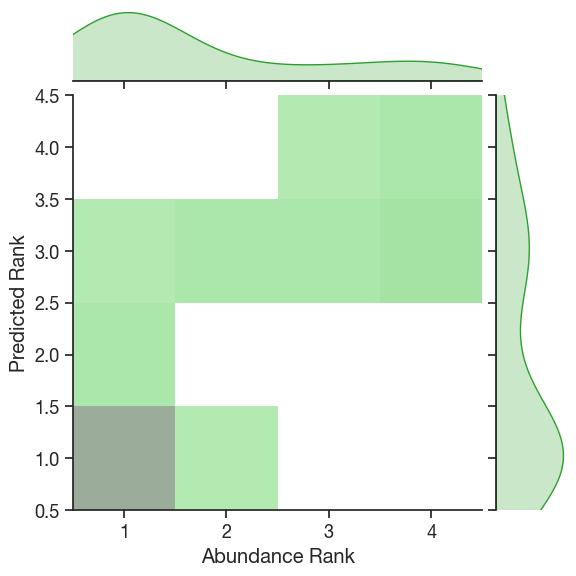

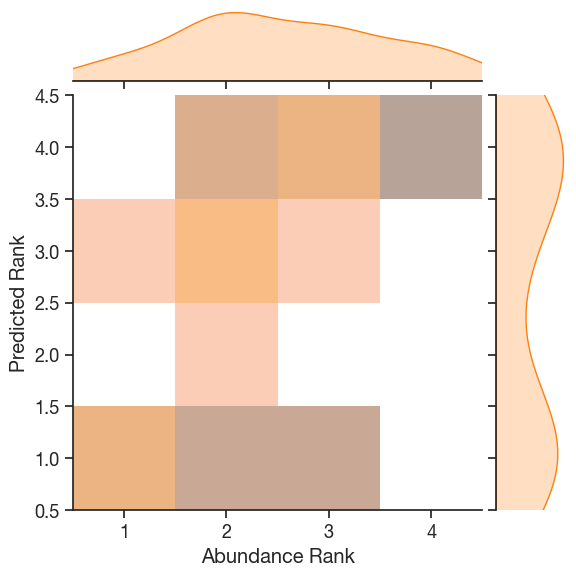

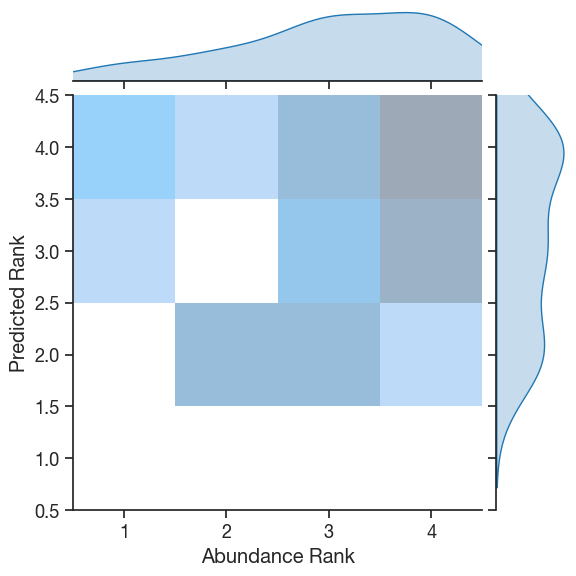

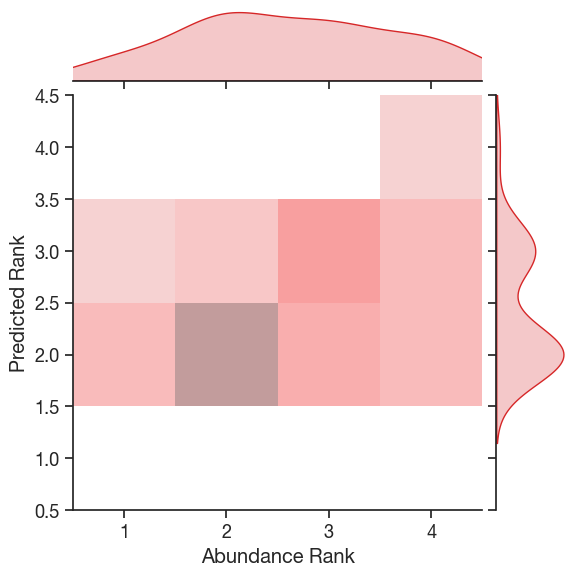

In [47]:


species_list = ['At', 'Ct', 'Ml', 'Oa']
# Define a discrete colormap
cmap = mcolors.ListedColormap(sns.color_palette("viridis", n_colors=4).as_hex())
norm = mcolors.BoundaryNorm(boundaries=[0.5, 1.5, 2.5, 3.5], ncolors=4)

# Loop through each species and create a jointplot
for i, s in enumerate(species_list):
    # Filter the data for the current species
    species_data = df_mean78[df_mean78['Species'] == s]
    
    # Create a jointplot for the current species
    g = sns.JointGrid(
        data=species_data,
        x='Abundance rank',
        y='Predicted rank',
        # kind='hist',  # Use KDE for the main plot
        # marginal_kws={'common_norm': False, 'fill': True},  # Density plots on the margins
        # bins=4,
        # height=6,
        # ratio=5
        # annotate=True,
        # dropna=True,
        # discrete=(True, True),
        
        # fill=True,  # Fill the KDE plot
        # color = palette[i],
        # cmap = cmap,
        # cbar=True,  # Add
        # thresh=None,
        # cbar_kws=dict(shrink=.75)
        # cmap='viridis'  # Choose a colormap
    )
    g.plot_joint(sns.histplot, alpha=.5, discrete=(True, True), color = palette[i], bins = 4)  
    g.plot_marginals(sns.kdeplot, color=palette[i], fill=True, common_norm=False)

        # Add a regression line to the main axes
    # sns.regplot(
    #     data=species_data,
    #     x='Abundance rank',
    #     y='Growth rate rank',
    #     scatter=False,  # Do not show scatter points (to avoid overlap with KDE)
    #     ax=g.ax_joint,
    #     color='black',  # Color of the regression line
    #     line_kws={'linewidth': 2}  # Customize the regression line
    # )
   
    g.ax_joint.set_xlim(0.5, 4.5)
    g.ax_joint.set_ylim(0.5, 4.5)
    plt.ylim(0.5, 4.5)
    # Customize the plot
    g.ax_joint.set_xlabel('Abundance Rank')
    g.ax_joint.set_ylabel('Predicted Rank')
    # g.ax_joint.set_title(f'Jointplot: {species}')

# PCA

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [49]:
df_mean78w = df.loc[df.Batch.isin([7,8])].groupby(['Well', 'Strain']).agg({'CFUs/mL':['mean', 'std'], 'Carbon source':'first'}).reset_index()
# df_mean78w.rename({'Strain':'Species'}, inplace = True)
df_mean78w.columns = ['Well', 'Species', 'Mean CFUs/mL', 'Std CFUs/mL', 'Carbon source']
df_mean78w['CS class'] = df_mean78w['Carbon source'].map(cs_to_class)
df_mean78w = pd.merge(left = df_mean78w, right = rate_df[['Carbon source', 'Growth rate rank', 'Species', 'max_growth_rate', '# CS', 'Effective growth rate', 'Effective growth rate rank']], on = ['Carbon source', 'Species'], how = 'left')


df_mean78w = df_mean78w.loc[df_mean78w['# CS'].isin([1,2])]

idx1 = df_mean78w['# CS'] == 1
idx2 = df_mean78w['# CS'] == 2


cfu_data = df_mean78w.pivot(index = ['Well'], columns = 'Species', values = 'Mean CFUs/mL')
cfu_data1 = df_mean78w.loc[idx1].pivot(index = ['Well'], columns = 'Species', values = 'Mean CFUs/mL')
# cfu_data.fillna(0, inplace=True)

# cfu_data.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data.reset_index()
log_cfu = np.log10(cfu_data)
log_cfu1 = np.log10(cfu_data1)


In [50]:
# Find the most abundant species for each well
most_abundant_species = df_mean78w.groupby('Well')['Mean CFUs/mL'].idxmax()

# Create a dictionary mapping wells to the most abundant species
well_to_aspecies = {
    well: df_mean78w.loc[idx, 'Species'] for well, idx in most_abundant_species.items()
}

# Display the resulting dictionary
print(well_to_aspecies)

df_mean78w['Abundance rank'] = df_mean78w.groupby(['Well']).rank(ascending=False, method='min')['Mean CFUs/mL']
well_to_at_rank = df_mean78w.loc[df_mean78w.Species=='At'].set_index('Well').to_dict()['Abundance rank']
well_to_ct_rank = df_mean78w.loc[df_mean78w.Species=='Ct'].set_index('Well').to_dict()['Abundance rank']
well_to_ml_rank = df_mean78w.loc[df_mean78w.Species=='Ml'].set_index('Well').to_dict()['Abundance rank']
well_to_oa_rank = df_mean78w.loc[df_mean78w.Species=='Oa'].set_index('Well').to_dict()['Abundance rank']


{'A1': 'Oa', 'A10': 'Oa', 'A11': 'Oa', 'A12': 'Oa', 'A2': 'At', 'A3': 'Oa', 'A4': 'At', 'A5': 'At', 'A6': 'At', 'A7': 'Oa', 'A8': 'Oa', 'A9': 'Oa', 'B1': 'At', 'B10': 'Ct', 'B11': 'Ct', 'B12': 'Ct', 'B2': 'At', 'B3': 'At', 'B4': 'At', 'B5': 'At', 'B6': 'At', 'B7': 'At', 'B8': 'At', 'B9': 'At', 'C1': 'At', 'C10': 'At', 'C11': 'At', 'C12': 'At', 'C2': 'At', 'C3': 'Oa', 'C4': 'Ct', 'C5': 'Ct', 'C6': 'Ct', 'C7': 'Oa', 'C8': 'Ml', 'C9': 'Ml', 'D1': 'At', 'D10': 'At', 'D11': 'At', 'D12': 'At', 'D2': 'At', 'D3': 'At', 'D4': 'At', 'D5': 'At', 'D6': 'At', 'D7': 'At', 'D8': 'At', 'D9': 'At', 'E1': 'At', 'E10': 'Ml', 'E11': 'Ml', 'E12': 'Ml', 'E2': 'At', 'E3': 'At', 'E4': 'Ct', 'E5': 'Ct', 'E6': 'Ct', 'E7': 'Ml', 'E8': 'Ml', 'E9': 'Ct', 'F1': 'Oa', 'F10': 'At', 'F11': 'At', 'F12': 'At', 'F2': 'Oa', 'F3': 'Oa', 'F4': 'At', 'F5': 'At', 'F6': 'At', 'F7': 'At', 'F8': 'At', 'F9': 'At', 'G1': 'At', 'G10': 'At', 'G11': 'At', 'G12': 'At', 'G2': 'At', 'G3': 'At', 'G4': 'At', 'G5': 'At', 'G6': 'At', 'G7': 

In [51]:
# Standardize the data
scaler = StandardScaler()
cfu_data_scaled = scaler.fit_transform(log_cfu)

# Perform PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_result = pca.fit_transform(cfu_data_scaled)

# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=cfu_data.index)
pca_df.columns = ['Principal component 1', 'Principal component 2']
pca_df['Carbon source class'] = pca_df.index.get_level_values('Well').map(well_to_class)
pca_df['Carbon source'] = pca_df.index.get_level_values('Well').map(well_to_cs)
pca_df['N CS'] = [2 if '+' in x else 1 for x in pca_df['Carbon source']]
pca_df['Most abundant species'] = pca_df.index.map(well_to_aspecies)
pca_df['At rank'] = pca_df.index.map(well_to_at_rank).astype(int)
pca_df['Ct rank'] = pca_df.index.map(well_to_ct_rank).astype(int)
pca_df['Ml rank'] = pca_df.index.map(well_to_ml_rank).astype(int)
pca_df['Oa rank'] = pca_df.index.map(well_to_oa_rank).astype(int)
pca_df['At r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='At'].set_index('Carbon source').to_dict()['max_growth_rate'])
pca_df['Ct r'] = pca_df['Carbon source'].map(rate_df.loc[rate_df.Species=='Ct'].set_index('Carbon source').to_dict()['max_growth_rate']) 

In [52]:
pca_fit= pca.fit(cfu_data_scaled)
print(log_cfu.columns, pca_fit.components_, pca_fit.explained_variance_ratio_)

Index(['At', 'Ct', 'Ml', 'Oa'], dtype='object', name='Species') [[ 0.61720745 -0.56762937 -0.47267014 -0.27098858]
 [ 0.1609331  -0.40580501  0.19378365  0.87856174]] [0.50184996 0.2440325 ]


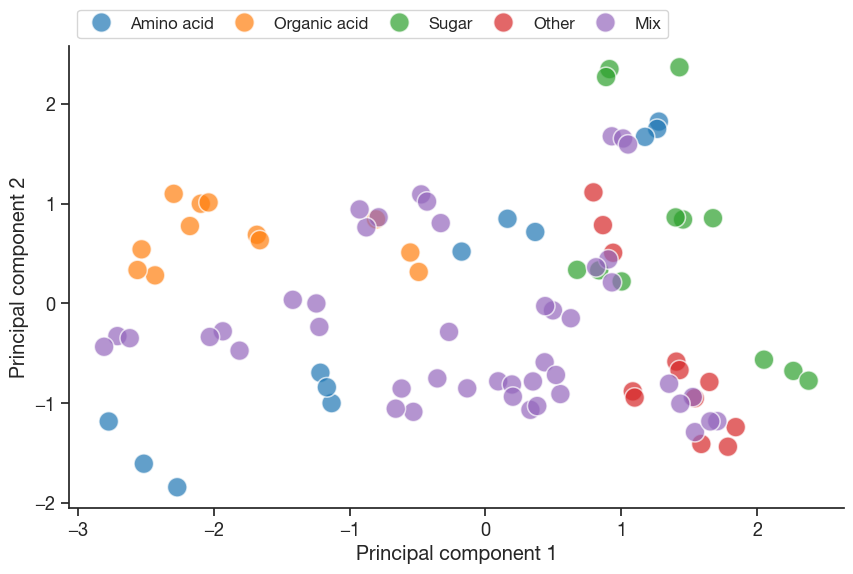

In [53]:
fig, ax = plt.subplots(figsize=(10,6))

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source class', s = 200, alpha = 0.7, 
                    hue_order=['Amino acid', 'Organic acid', 'Sugar', 'Other', 'Mix'], palette = 'tab10')
sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,1), ncol=5,
                fontsize='small',  # Reduce the font size of legend labels
                title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8)
# plt.tight_layout()
plt.savefig(figure_folder / 'pca_cs_class.pdf', bbox_inches='tight')

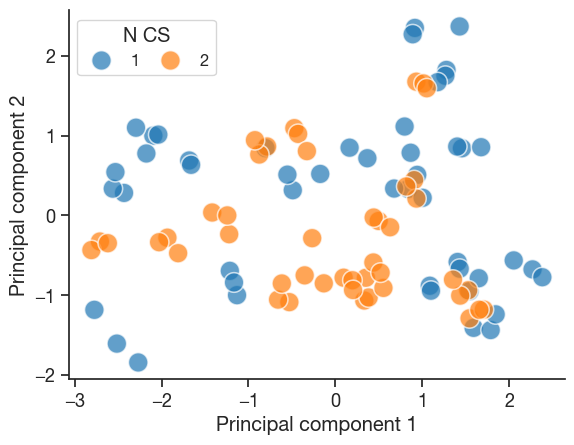

In [54]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'N CS', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
# sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))
plt.savefig(figure_folder / 'PCA_n_cs.pdf')

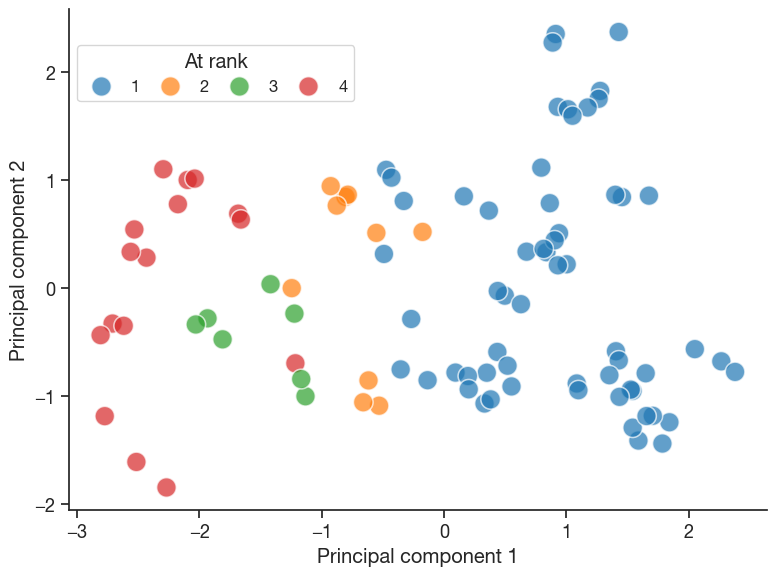

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'At rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 'lower left', bbox_to_anchor = (0,0.8), ncol=4,
                fontsize='small',  # Reduce the font size of legend labels
                # title='',
    labelspacing=0.5,  # Reduce spacing between labels
    columnspacing=0.8
                )
plt.tight_layout()
plt.savefig(figure_folder / 'pca_growth_rate_rank_at.pdf')

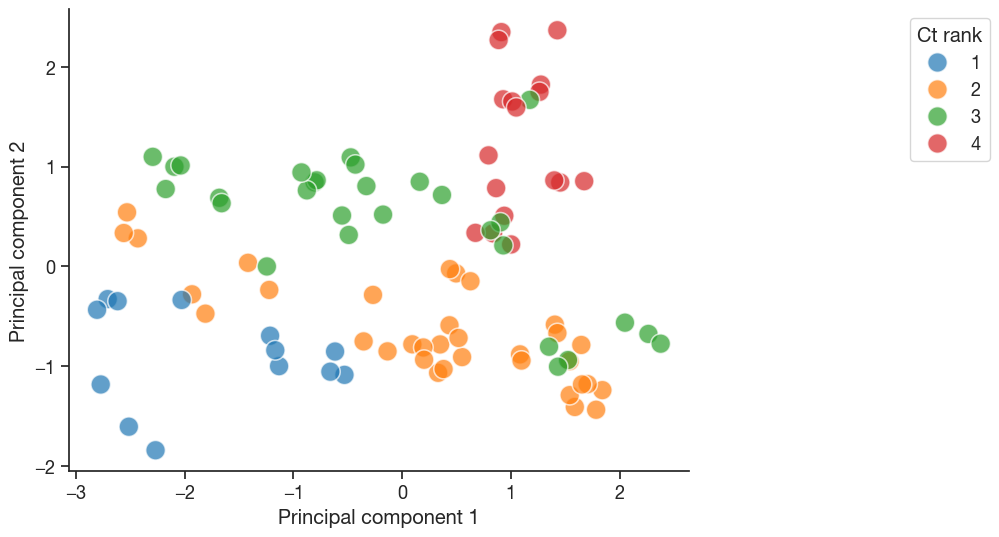

In [56]:
fig, ax = plt.subplots(figsize=(8, 6))
g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

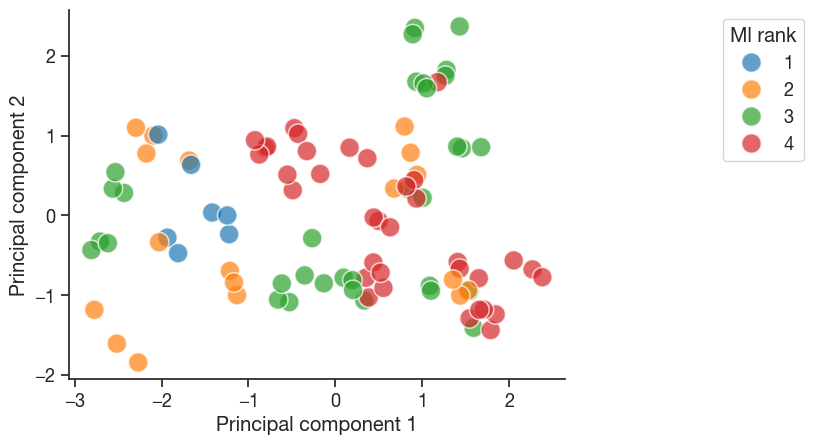

In [57]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ml rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

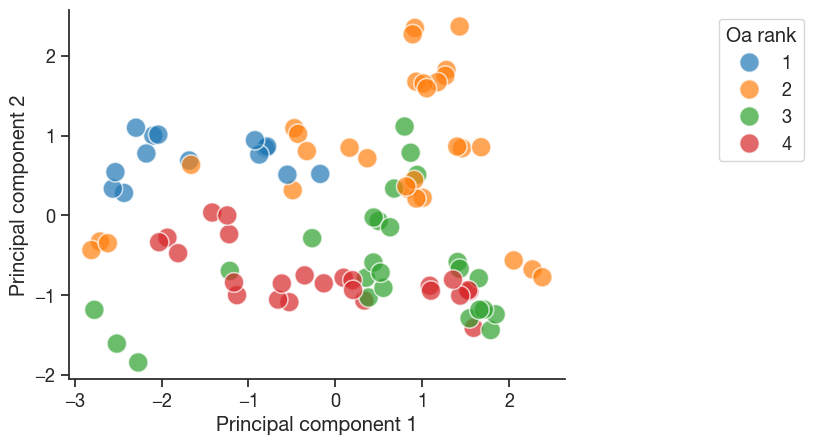

In [58]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Oa rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

In [59]:
pca_df.to_csv(data_folder / 'pca.csv')

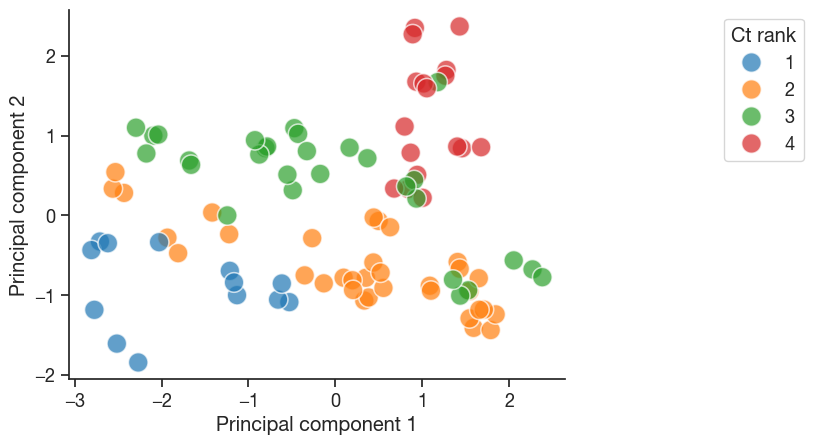

In [60]:

g = sns.scatterplot(pca_df, x = 'Principal component 1', y = 'Principal component 2', hue = 'Ct rank', s = 200, alpha = 0.7, palette = 'tab10')

sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))

# Correlations

In [61]:
cfu_data_all = df.pivot(index = ['Well', 'Batch'], columns = 'Strain', values = 'CFUs/mL')
cfu_data_all.drop(index=['H10', 'H11', 'H12'], inplace=True)
cfu_data_all.reset_index()
log_cfu_all = np.log10(cfu_data_all)


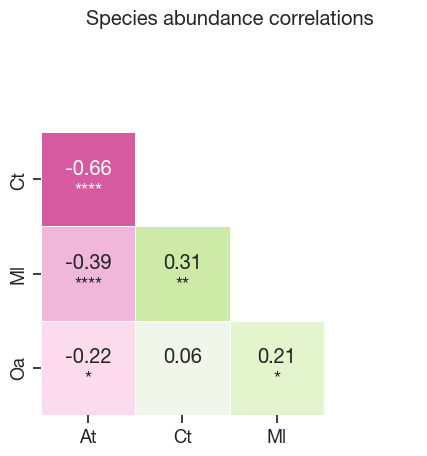

In [62]:
# Compute the correlation matrix
# Create a figure and gridspec to position the color bar
# fig, ax = plt.subplots(figsize=(6, 6))
# cbar_ax = fig.add_axes([0.6, 0.4, 0.02, 0.3])  # [left, bottom, width, height]
corr_matrix = log_cfu.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool),0)

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(log_cfu[s1], log_cfu[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = corr_matrix.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(corr_matrix, mask=mask, cmap='PiYG', vmin = -1, vmax = 1, cbar = False, square=True, 
            annot = annot_matrix.where(~mask,''),
            fmt = 's',
            # fmt = '.2f', 
            linewidths=0.5, linecolor='white',
            # ax=ax, 
            # cbar_ax=cbar_ax, cbar_kws={'shrink':0.3, 'label': 'Correlation Coefficient', 'orientation': 'vertical'}
            )
plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  




# ax.set_xticklabels(ax.get_xticklabels())  # Exclude the last tick label
plt.title('Species abundance correlations', pad = 10)
plt.tight_layout()
plt.savefig(figure_folder / 'species_abundance_correlations.pdf', bbox_inches='tight')
plt.show()


In [63]:
df_mean78w['Carbon source'].unique()

array(['Acetate', 'Glutarate', 'Glucose', 'Citrate', 'Glycerol',
       'Glutamate', 'Inosine', 'Alanine', 'Histidine', 'Mannitol',
       'Isoleucine', 'Malate', 'Mannose', 'Ribose', 'Myo-inositol',
       'Xylose', 'Citrate + Glucose', 'Malate + Citrate',
       'Glycerol + Isoleucine', 'Glutarate + Inosine',
       'Acetate + Alanine', 'Mannitol + Acetate', 'Glutamate + Mannose',
       'Histidine + Mannose', 'Myo-inositol + Glutamate',
       'Glycerol + Inosine', 'Ribose + Glutarate', 'Xylose + Histidine',
       'Alanine + Glucose', 'Malate + Isoleucine',
       'Mannitol + Myo-inositol'], dtype=object)

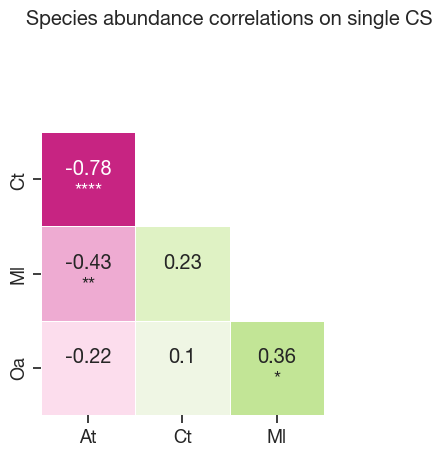

In [119]:
# Compute the correlation matrix
# Create a figure and gridspec to position the color bar
# fig, ax = plt.subplots(figsize=(6, 6))
# cbar_ax = fig.add_axes([0.6, 0.4, 0.02, 0.3])  # [left, bottom, width, height]
# corr_matrix = log_cfu_all.corr()

corr_matrix1 = log_cfu1.corr()
mask = np.triu(np.ones_like(corr_matrix1, dtype=bool),0)

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(log_cfu1[s1], log_cfu1[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = corr_matrix1.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(corr_matrix1, mask=mask, cmap='PiYG', vmin = -1, vmax = 1, cbar = False, square=True, 
            annot = annot_matrix.where(~mask,''),
            fmt = 's',
            # fmt = '.2f', 
            linewidths=0.5, linecolor='white',
            # ax=ax, 
            # cbar_ax=cbar_ax, cbar_kws={'shrink':0.3, 'label': 'Correlation Coefficient', 'orientation': 'vertical'}
            )
plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  




# ax.set_xticklabels(ax.get_xticklabels())  # Exclude the last tick label
plt.title('Species abundance correlations on single CS', pad = 10)
plt.tight_layout()
plt.savefig(figure_folder / 'species_abundance_correlations_1cs.pdf', bbox_inches='tight')
plt.show()


In [65]:
p_matrix

,At,Ct,Ml,Oa
At,0.0,0.0,0.002177,0.13613
Ct,0.0,0.0,0.108949,0.501922
Ml,0.002177,0.108949,0.0,0.012766
Oa,0.13613,0.501922,0.012766,0.0


Text(0.5, 1.0, 'Effective growth rate correlations')

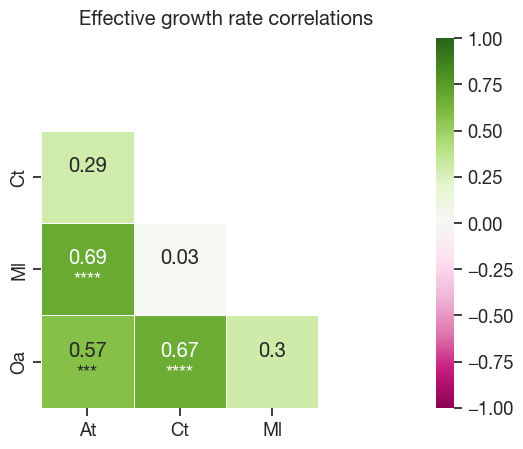

In [68]:

egr_matrix = df_mean78.pivot(index='Carbon source', columns='Species', values='Effective growth rate')
egr_corr = egr_matrix.corr()

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        r, p = st.pearsonr(egr_matrix[s1], egr_matrix[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = egr_corr.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(egr_corr,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=annot_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='',  # Use string format since we're providing custom annotations

            mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  
plt.title('Effective growth rate correlations', pad = 10)

In [245]:
rate_df.loc[rate_df.Species=='Ct'].sort_values(by = 'Effective growth rate rank')

,Species,Carbon source,model,RSS,RMSD,bic,aic,weighted_bic,weighted_aic,y0,...,has_nu,max_growth_rate,min_doubling_time,lag,Binary growth evaluation,Yield,# CS,Effective growth rate,Growth rate rank,Effective growth rate rank
34,Ct,Acetate,Model(RichardsLag1),0.086861,0.022343,-1297.039697,-1312.834974,0.909761,0.675066,0.050437,...,True,0.335427,2.089089,9.076544,1.0,1.173000,1,0.060819,1.0,1.0
62,Ct,Pyruvate,Model(BaranyiRoberts),0.662165,0.039151,-2763.237364,-2787.647918,0.999645,0.999954,0.046422,...,True,0.293390,2.399552,14.022411,1.0,0.897467,1,0.035287,1.0,1.0
54,Ct,Leucine,Model(RichardsLag1),0.125570,0.020667,-2252.573025,-2270.990924,0.870538,0.515977,0.055218,...,True,0.191179,3.726671,18.465121,1.0,1.192667,1,0.032934,1.0,1.0
53,Ct,Lactate,Model(BaranyiRoberts),0.109317,0.027553,-1004.578729,-1022.397608,0.626575,0.881055,0.047642,...,True,0.415010,1.680708,8.985932,1.0,1.275333,1,0.072615,1.0,1.0
52,Ct,Isoleucine,Model(LogisticLag2),0.295598,0.025545,-3292.016119,-3312.595579,0.930282,0.630201,0.048726,...,False,0.078777,8.991839,51.320662,1.0,0.998000,1,0.010589,1.0,1.0
49,Ct,Glycine,Model(RichardsLag1),0.131432,0.017690,-3358.998722,-3379.199995,0.749439,0.372460,0.048112,...,True,0.140385,5.044044,36.066296,1.0,0.587667,1,0.010012,1.0,1.0
67,Ct,No cs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000000,NaN,NaN,0.0,0.004333,0,0.000000,1.0,1.0
60,Ct,Phenylalanine,Model(RichardsLag1),0.105280,0.016305,-3230.182161,-3250.089232,0.549410,0.142776,0.055620,...,True,0.120398,5.944695,22.318415,1.0,0.932000,1,0.019164,1.0,1.0
45,Ct,Glutamate,Model(RichardsLag1),0.111314,0.029723,-861.810821,-875.992230,0.892264,0.667302,0.046947,...,True,0.568946,1.197406,5.090895,1.0,1.349000,1,0.118441,1.0,1.0
46,Ct,Glutamine,Model(Richards),0.117829,0.028605,-1003.720905,-1015.600158,0.917197,0.665241,0.007278,...,True,0.415968,0.984415,4.735938,1.0,1.341000,1,0.077200,1.0,1.0


Text(0.5, 1.0, 'Effective growth rate correlations 1 cs')

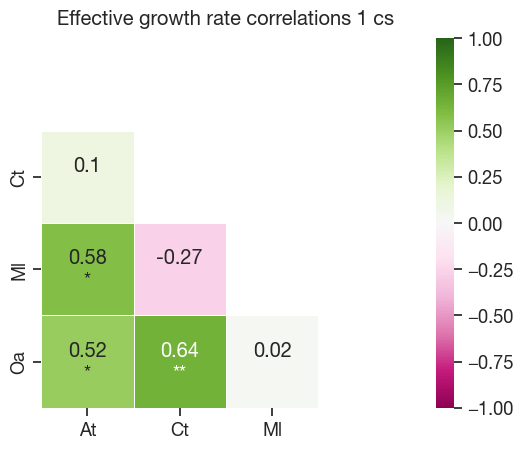

In [ ]:
idx1 = df_mean78['# CS'] == 1
egr_matrix = df_mean78.loc[idx1].pivot(index='Carbon source', columns='Species', values='Effective growth rate')
egr_corr = egr_matrix.corr()

p_matrix = pd.DataFrame(index = species_list, columns = species_list)
# Annotate with significance stars
for s1 in species_list:
    for s2 in species_list:
        # r, p = st.spearmanr(egr_matrix[s1], egr_matrix[s2])
        r, p = st.pearsonr(egr_matrix[s1], egr_matrix[s2])
        # corr_dict[(s1,s2)] = r
        p_matrix.loc[s1,s2] = p

# Create significance annotation matrix
sig_matrix = p_matrix.map(lambda p: '****' if p < 0.0001 else '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else '')

# Create custom annotations combining correlation values and significance
annot_matrix = egr_corr.round(2).astype(str) + '\n' + sig_matrix


ax = sns.heatmap(egr_corr,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=annot_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='',  # Use string format since we're providing custom annotations

            mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  
plt.title('Effective growth rate correlations 1 cs', pad = 10)

In [ ]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Shannon index,Prediction diff
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.017602,3.0,3.0,1.714035,1.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.038394,3.0,3.0,1.752692,1.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0,0.020792,2.0,1.0,1.065604,0.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0,0.077715,2.0,1.0,0.958611,0.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0,0.000000,4.0,4.0,1.566223,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Oa,Myo-inositol + Glutamate,1.533333e+08,4.320494e+07,3.0,1.0,0.613915,2.0,0.081695,3.0,3.0,1.096538,0.0
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0,0.015348,3.0,3.0,0.997872,1.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0,0.053914,1.0,2.0,1.441160,-2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0,0.030161,2.0,2.0,0.156391,0.0


In [ ]:
df_mean78.pivot(index='Carbon source', columns='Species', values='max_growth_rate')

Species,At,Ct,Ml,Oa
Carbon source,,,,
Acetate,0.095601,0.335427,0.069082,0.227276
Acetate + Alanine,0.228739,0.361459,0.133624,0.645410
Alanine,0.133138,0.026032,0.064542,0.418134
Alanine + Glucose,0.372152,0.026032,0.188151,0.757449
Citrate,0.000000,0.116124,0.118920,0.137495
Citrate + Glucose,0.239014,0.116124,0.242528,0.476810
Glucose,0.239014,0.000000,0.123609,0.339315
Glutamate,0.204759,0.568946,0.089860,0.308978
Glutamate + Mannose,0.388057,0.568946,0.216858,0.469366


# Niche overlap

In [72]:
rate_binary = rate_df.loc[rate_df['# CS'] == 1].pivot(columns = 'Species', index = 'Carbon source', values = 'Binary growth evaluation')

In [110]:
noi_matrix = pd.DataFrame(np.zeros((4,4)), index = species_list, columns = species_list)

for i, s1 in enumerate(species_list):
    for s2 in species_list:
        noi_matrix.loc[s1,s2] = sum(rate_binary[[s1, s2]].all(axis=1))/sum(rate_binary[[s1, s2]].any(axis=1))

Text(0.5, 1.0, 'Niche overlap index')

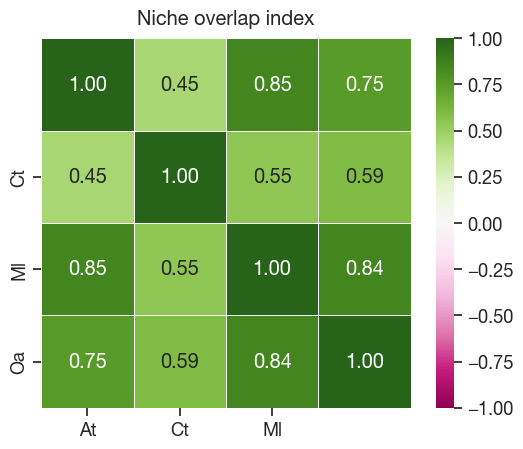

In [117]:

ax = sns.heatmap(noi_matrix,
            cmap='PiYG', vmin = -1, vmax = 1, square=True, 
            annot=True,#noi_matrix.where(~mask, ''),  # Only annotate lower triangle
            fmt='.2f',  # Use string format since we're providing custom annotations

            # mask = np.triu(np.ones((4,4)),0),
            # fmt = '.2f',
            linewidths=0.5, linecolor='white',
            )

plt.xlabel('')
plt.ylabel('')
ax.set_xticks(ax.get_xticks()[:-1])  # Exclude the last tick
ax.set_yticks(ax.get_yticks()[1:])  
plt.title('Niche overlap index', pad = 10)

# Relative abundance

In [153]:
# Calculate relative abundances
rel_abundances = cfu_data.T / cfu_data.sum(axis=1).T
rel_abu_long = rel_abundances.T.reset_index().melt(
    id_vars='Well', 
    var_name='Species', 
    value_name='Rel. abundance'
)

In [156]:
rel_abu_long['Carbon source'] = rel_abu_long.Well.map(well_to_cs)

In [ ]:
rel_abu_long.groupby(['Species', 'Carbon source'])['Rel.abundance.']

In [181]:
df_mean78

,Species,Carbon source,Mean CFUs/mL,Std CFUs/mL,Abundance rank,Growth rate rank,max_growth_rate,# CS,Effective growth rate,Effective growth rate rank,Predicted rank,Shannon index,Prediction diff
0,At,Acetate,9.333333e+08,3.932768e+08,2.0,3.0,0.095601,1.0,0.017602,3.0,3.0,1.714035,1.0
1,At,Acetate + Alanine,1.400000e+09,2.828427e+08,2.0,3.0,0.228739,2.0,0.038394,3.0,3.0,1.752692,1.0
2,At,Alanine,3.733333e+09,4.501851e+08,1.0,2.0,0.133138,1.0,0.020792,2.0,1.0,1.065604,0.0
3,At,Alanine + Glucose,6.666667e+09,2.927570e+09,1.0,2.0,0.372152,2.0,0.077715,2.0,1.0,0.958611,0.0
4,At,Citrate,1.000000e+08,3.651484e+07,4.0,4.0,0.000000,1.0,0.000000,4.0,4.0,1.566223,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,Oa,Myo-inositol + Glutamate,1.533333e+08,4.320494e+07,3.0,1.0,0.613915,2.0,0.081695,3.0,3.0,1.096538,0.0
124,Oa,Ribose,3.760000e+09,8.648699e+08,2.0,1.0,0.103032,1.0,0.015348,3.0,3.0,0.997872,1.0
125,Oa,Ribose + Glutarate,1.500000e+08,8.648699e+07,4.0,1.0,0.414995,2.0,0.053914,1.0,2.0,1.441160,-2.0
126,Oa,Xylose,5.266667e+07,1.573107e+07,2.0,2.0,0.215384,1.0,0.030161,2.0,2.0,0.156391,0.0


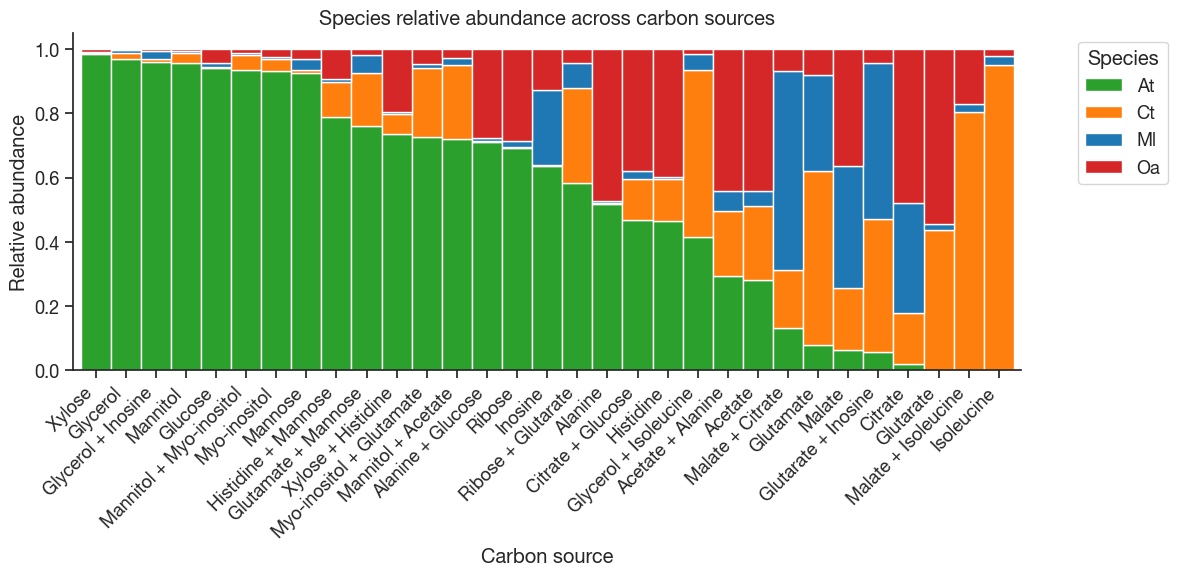

In [203]:
# Create a stacked barplot of relative abundances by carbon source
fig, ax = plt.subplots(figsize=(12, 6))

# Pivot the data to get species as columns
# rel_abu_pivot = rel_abu_long.pivot(index='Carbon source', columns='Species', values='Rel. abundance')
df_mean_pivot = df_mean78.pivot(index = 'Carbon source', columns = 'Species', values = 'Mean CFUs/mL')
# Calculate relative abundances (normalize each row to sum to 1)
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

df_rel_abu = df_rel_abu.round(3)
df_rel_abu.sort_values(by = ['At', 'Oa'],ascending = False, inplace = True)
# Create stacked bar plot
df_rel_abu[species_list].plot(kind='bar', stacked=True, ax=ax, color=palette, width=1)

plt.xlabel('Carbon source')
plt.ylabel('Relative abundance')
plt.title('Species relative abundance across carbon sources')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
plt.show()

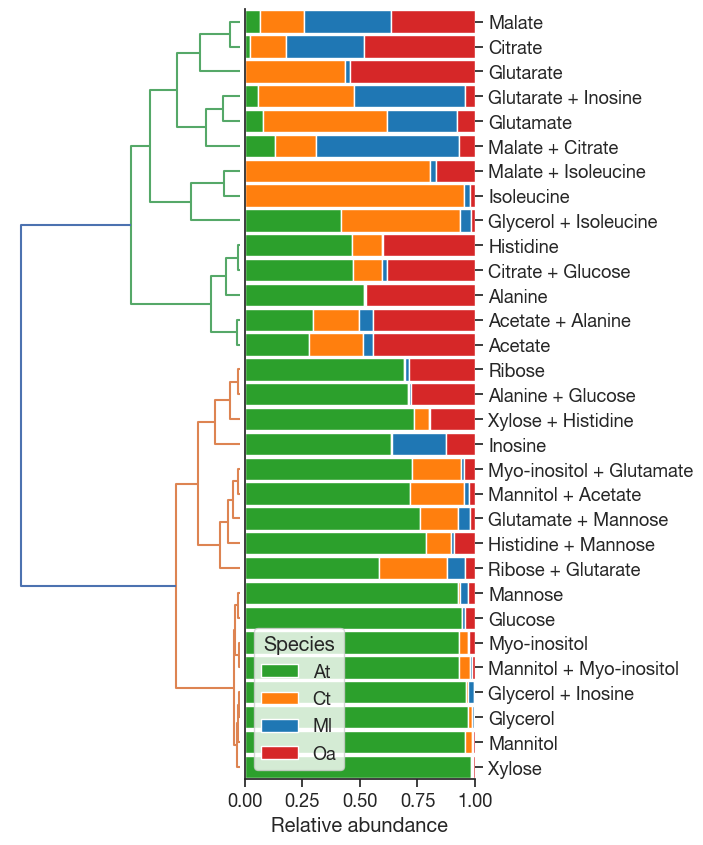

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.gridspec as gridspec

# Pivot and calculate relative abundances
df_mean_pivot = df_mean78.pivot(index='Carbon source', columns='Species', values='Mean CFUs/mL')
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

# Perform hierarchical clustering
linkage_matrix = linkage(df_rel_abu[species_list], method='ward')

# Get the dendrogram to extract order
dendro = dendrogram(linkage_matrix, no_plot=True)
clustered_order = dendro['leaves']
df_rel_abu_clustered = df_rel_abu.iloc[clustered_order]

# Create figure with custom gridspec
fig = plt.figure(figsize=(6, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.02)

# Plot dendrogram
ax1 = plt.subplot(gs[0])
dendro = dendrogram(linkage_matrix, ax=ax1, orientation='left', no_labels=True)
# ax1.set_xlabel('Distance')
# ax1.set_title('Hierarchical Clustering')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.xaxis.tick_top()  # Move x-axis ticks to top
ax1.xaxis.set_label_position('top')  # Move x-axis label to top


# Create stacked bar plot
ax2 = plt.subplot(gs[1])
df_rel_abu_clustered[species_list].plot(kind='barh', stacked=True, ax=ax2, color=palette, width=0.9)
ax2.set_ylabel('')
# ax2.xaxis.tick_top()  # Move x-axis ticks to top
# ax2.xaxis.set_label_position('top')  # Move x-axis label to top
ax2.set_xlabel('Relative abundance')
ax2.yaxis.tick_right()  # Move y-axis ticks to right
ax2.yaxis.set_label_position('right')  # Move y-axis label to right
ax2.set_xlim(0,1)
# ax2.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')

# Align dendrogram with bars
n_samples = len(df_rel_abu_clustered)
ax1.set_ylim(0, n_samples * 10)  # Match dendrogram scaling
ax2.set_ylim(-0.5, n_samples - 0.5)

sns.despine(ax=ax2)
plt.savefig(figure_folder / 'relative_abundance_with_dendrogram.pdf', bbox_inches='tight')
plt.show()

In [246]:
df_rel_abu_clustered

Species,At,Ct,Ml,Oa
Carbon source,,,,
Xylose,0.982913,0.005486,0.002572,0.009029
Mannitol,0.955968,0.031190,0.005504,0.007339
Glycerol,0.968452,0.017608,0.010565,0.003375
Glycerol + Inosine,0.959364,0.010388,0.025665,0.004583
Mannitol + Myo-inositol,0.932577,0.047637,0.004915,0.014871
Myo-inositol,0.931268,0.038734,0.003626,0.026372
Glucose,0.941404,0.002398,0.011812,0.044386
Mannose,0.924248,0.011870,0.031714,0.032167
Ribose + Glutarate,0.584158,0.296040,0.075248,0.044554


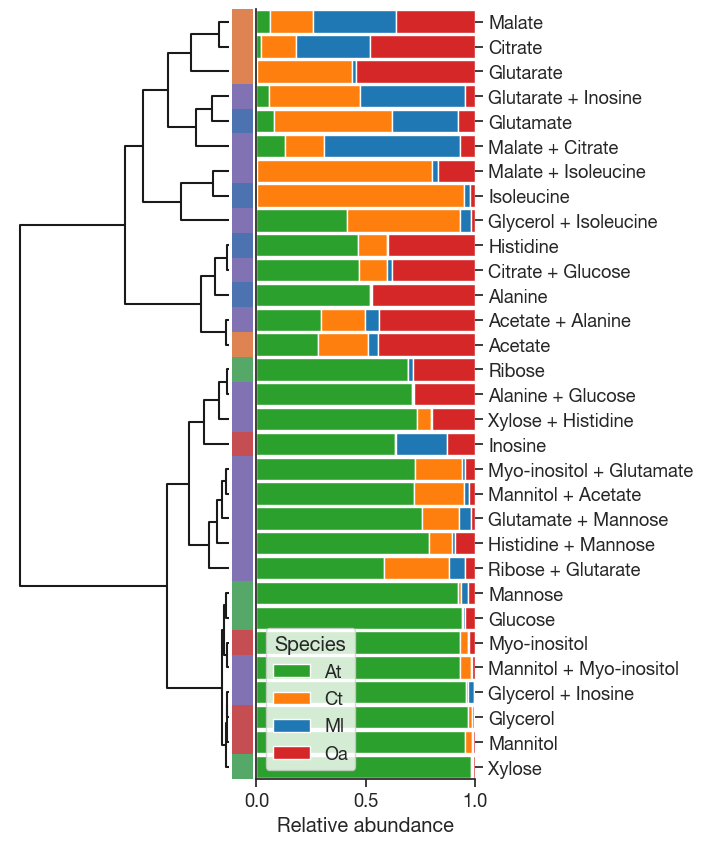

In [244]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.gridspec as gridspec

# Pivot and calculate relative abundances
df_mean_pivot = df_mean78.pivot(index='Carbon source', columns='Species', values='Mean CFUs/mL')
df_rel_abu = df_mean_pivot.div(df_mean_pivot.sum(axis=1), axis=0)

# Perform hierarchical clustering
linkage_matrix = linkage(df_rel_abu[species_list], method='ward')

# Get the dendrogram to extract order
dendro = dendrogram(linkage_matrix, no_plot=True)
clustered_order = dendro['leaves']
df_rel_abu_clustered = df_rel_abu.iloc[clustered_order]

# Create color mapping for carbon source classes
cs_classes = df_rel_abu_clustered.index.map(cs_to_class)
class_palette = {'Amino acid': 'C0', 'Organic acid': 'C1', 'Sugar': 'C2', 'Other': 'C3', 'Mix': 'C4'}
row_colors = cs_classes.map(class_palette)

# Create figure with custom gridspec - add space for color bar
fig = plt.figure(figsize=(6, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[2, 0.2, 2], wspace=0.02)

# Plot dendrogram
ax1 = plt.subplot(gs[0])
dendro = dendrogram(linkage_matrix, ax=ax1, orientation='left', no_labels=True, color_threshold=0, above_threshold_color='k')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.set_yticks([])
ax1.set_xticks([])
ax1.xaxis.tick_top()
ax1.xaxis.set_label_position('top')

# Add color bar for categories
ax_colors = plt.subplot(gs[1])
n_samples = len(df_rel_abu_clustered)
for i, cs in enumerate(df_rel_abu_clustered.index):
    cs_class = cs_to_class.get(cs, 'Mix')
    color = class_palette[cs_class]
    ax_colors.barh(i, 1, color=color, height=1, edgecolor='none')
ax_colors.set_ylim(-0.5, n_samples - 0.5)
ax_colors.set_xlim(0, 1)
ax_colors.axis('off')


# Create stacked bar plot
ax2 = plt.subplot(gs[2])
df_rel_abu_clustered[species_list].plot(kind='barh', stacked=True, ax=ax2, color=palette, width=0.9)
ax2.set_ylabel('')
ax2.set_xlabel('Relative abundance')
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position('right')
ax2.set_xlim(0,1)

# Align dendrogram with bars
ax1.set_ylim(0, n_samples * 10)
ax2.set_ylim(-0.5, n_samples - 0.5)

sns.despine(ax=ax2)
plt.savefig(figure_folder / 'relative_abundance_with_dendrogram.pdf', bbox_inches='tight')
plt.show()



<Axes: xlabel='Rel. abundance', ylabel='Density'>

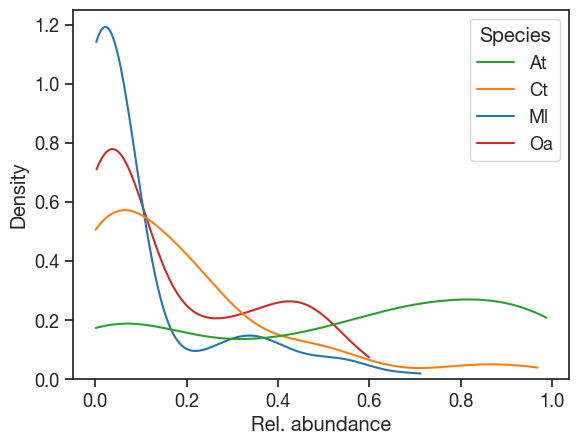

In [168]:
sns.kdeplot(rel_abu_long, x = 'Rel. abundance', hue = 'Species', hue_order=species_list, palette = palette, cut = 0)
# plt.yscale('log')

<Axes: xlabel='lag', ylabel='max_growth_rate'>

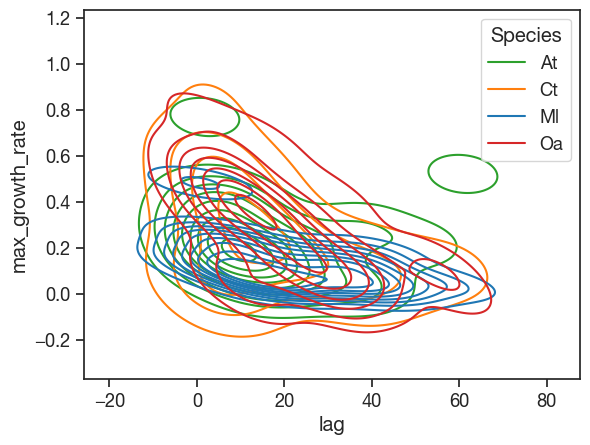

In [256]:
sns.kdeplot(rate_df, x = 'lag', y = 'max_growth_rate', hue = 'Species', hue_order = species_list, palette=palette)

In [ ]:
seven_cs = ['Acetate', 'Glutamate', 'Glutarate', 'Histidine', 'Inosine', 'Malate', 'Ribose']
for cs in seven_cs:
    idxcs = rate_df['Carbon source'] == cs
    sns.scatterplot()

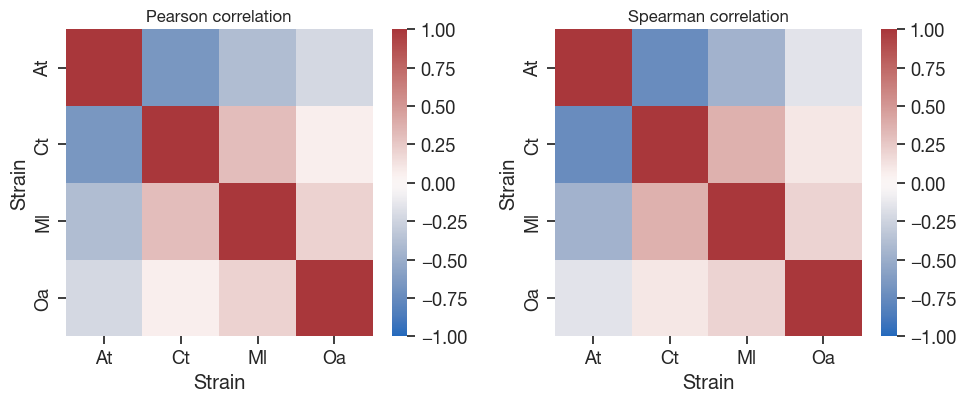

In [ ]:
fig, axes = plt.subplots(1,2, figsize = (10,4))
sns.heatmap(log_cfu.corr(), cmap='vlag', vmin = -1, vmax = 1, ax = axes[0], cbar = True, square=True,)
sns.heatmap(log_cfu.corr(method = 'spearman'), cmap='vlag', vmin = -1, vmax = 1, ax = axes[1], square=True)
axes[0].set_title('Pearson correlation', size = 12)
axes[1].set_title('Spearman correlation', size = 12)
plt.tight_layout()

In [ ]:
pca_mean = pca_df.groupby('Carbon source').mean(['Principal component 1',	'Principal component 2'])
pca_mean['N CS'] = [2 if '+' in x else 1 for x in pca_mean.index]

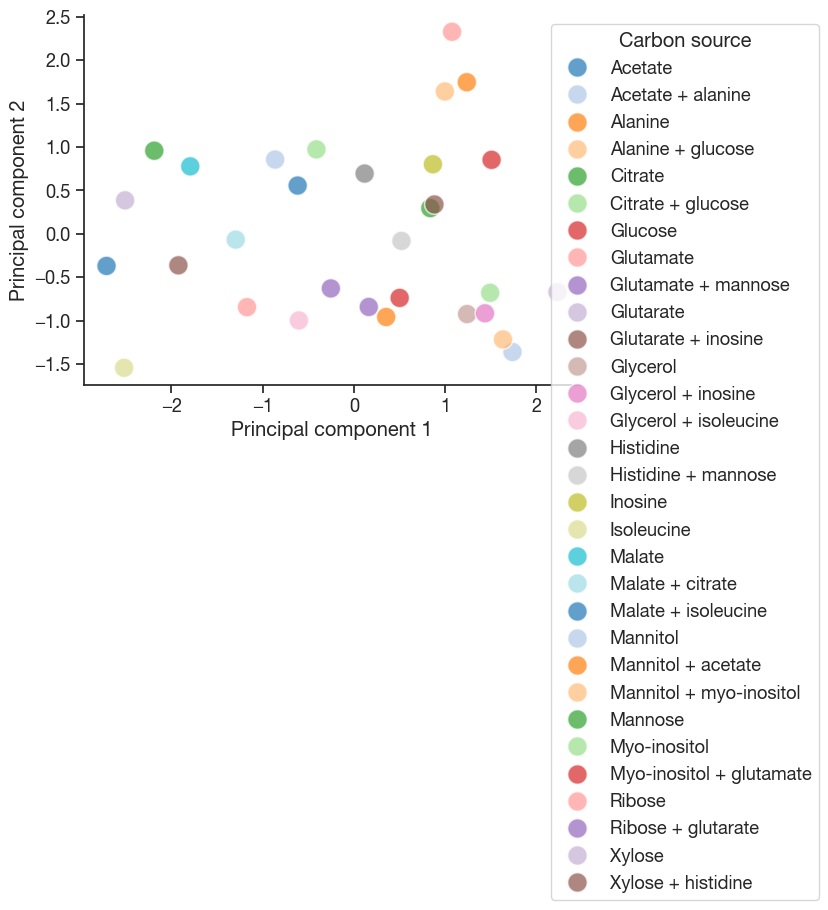

In [ ]:

g = sns.scatterplot(pca_mean, x = 'Principal component 1', y = 'Principal component 2', hue = 'Carbon source', s = 200, alpha = 0.7, 
                    palette = 'tab20'
                    )
sns.despine()
sns.move_legend(g, loc = 1, bbox_to_anchor = (1,0.5,0.5,0.5))